In [2]:
import os
import uuid
import chromadb
import numpy as np
from langchain_chroma import Chroma
from langchain_experimental.open_clip import OpenCLIPEmbeddings
from dotenv import load_dotenv
from IPython.display import HTML, display


from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import HumanMessage, SystemMessage

from langchain_openai import ChatOpenAI


import base64
import io
from io import BytesIO
import numpy as np
from PIL import Image

import pymupdf 

In [3]:
load_dotenv()

True

# Multimodal RAG with LangChain and CLIP

This notebook demonstrates how to build a Retrieval-Augmented Generation (RAG) system that can operate on both text and images. We will explore two primary approaches:

1.  **RAG over Raw Images:** Treating entire images as the documents for retrieval.
2.  **RAG over Parsed Documents:** Extracting and embedding text and images from a document separately for more granular retrieval.

We will use the `OpenCLIP` model for generating multimodal embeddings and a `ChromaDB` vector store to store them. The generation component will be handled by a multimodal Large Language Model.

### Approach 1 : Perform RAG over raw images

In this first approach, our knowledge base consists entirely of images. We will embed these images directly into a vector store. When a user asks a text-based question, the system will retrieve the most semantically relevant images and pass them to a multimodal LLM to generate a text-based answer.

In [4]:
# Initialize Vector store -> ChromaDB
# We specify a collection name and a directory to save our database locally.
# The key part is the embedding_function=OpenCLIPEmbeddings(), which will create our multimodal embeddings.

vector_store = Chroma(
    collection_name="mm_rag_clip_photos1",
    embedding_function=OpenCLIPEmbeddings(),
    persist_directory="./chroma_db",  # Where to save data locally
)



/Users/arvindna/Desktop/RAG-Workshop2/RAG_WS2_Final/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Load and Embed Images

image_path = './RAG-Part1-Images'
image_uris = [ os.path.join(image_path, image_name) for image_name in os.listdir(image_path)]

#add image (embeddings) to vector store
vector_store.add_images(uris=image_uris)

['820fff7b-f607-4e90-9629-bc42fda19c0f',
 '61704518-a732-4810-8b1a-d35600b3b928',
 'bda1428d-51e4-4b88-85ef-34e375da1beb',
 'db1a89f3-fe30-4cd7-9a57-e2f63f2af4c7',
 '3a3335bd-f3d7-48a7-a8a9-a8b78fd290fb',
 'd9bb339f-8f69-4506-8335-b1d9e9972226',
 '8cbd8a0a-331e-4d74-a58f-413f0c7d5886',
 '2d4ec12a-0bdf-4dc2-801e-4f7f775d6a74',
 'faf08092-71e6-4934-ad38-4d29b3ac2507',
 '480f1f8a-0277-4740-ab4d-da5d80dae30f',
 '56640ba6-4716-4bfc-96eb-f4251a18ab18',
 '666e49fe-1350-4b9d-b152-56bda4b31417',
 'c8127aff-38ea-46de-b964-f69ebcab28c3',
 '32384a0e-0b47-45a3-bae8-b4215dd17925',
 'd470d17f-3ca6-4246-b90f-2a740ab679fe',
 'b154600c-9058-41b5-a899-a8fcde9ccbf7',
 'c3a9dfc6-ee4f-4bc4-9dc9-7e76a5f791c6',
 '65b82070-fe85-4ac7-88be-ec0df5aa08f8',
 'd21ae36b-e96b-4e0b-aa57-94584797f924',
 'f7f4c41a-734f-4978-a3fe-63bacacfce2b',
 '89376d69-2a6c-470e-9d2e-c3f9f4abe7e2',
 'e88494a8-631e-4d18-9ecf-0024b21af6bd',
 '35a7dd65-014b-4ab7-b65c-ab1d41fab3fe',
 '2240d5f1-5129-4867-b54d-399da0e5353a',
 '855b9f1c-9a3e-



With our images embedded and stored, we can create a retriever. The retriever is a component that takes a user's query, embeds it using the same OpenCLIP model, and searches the vector store for the "top-k" most similar vector embeddings. 

In [6]:
# create a retreiver. Configure to extract Top n similar docs 

retriever = vector_store.as_retriever(search_kwargs={"k": 3})

In [7]:
# This helper function to render base64-encoded images directly within the notebook. This is useful for visualizing the images that our retriever fetches.
def plt_img_base64(img_base64):
    # Create an HTML img tag with the base64 string as the source
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'

    # Display the image by rendering the HTML
    display(HTML(image_html))

##### Test the Retriever

Let's test the retriever with a text query. The `retriever.invoke()` method will embed the question and perform a similarity search against the image embeddings in the vector store. The output `docs` will contain the retrieved images, which we can then display. Notice how a text query successfully retrieves relevant diagrams.


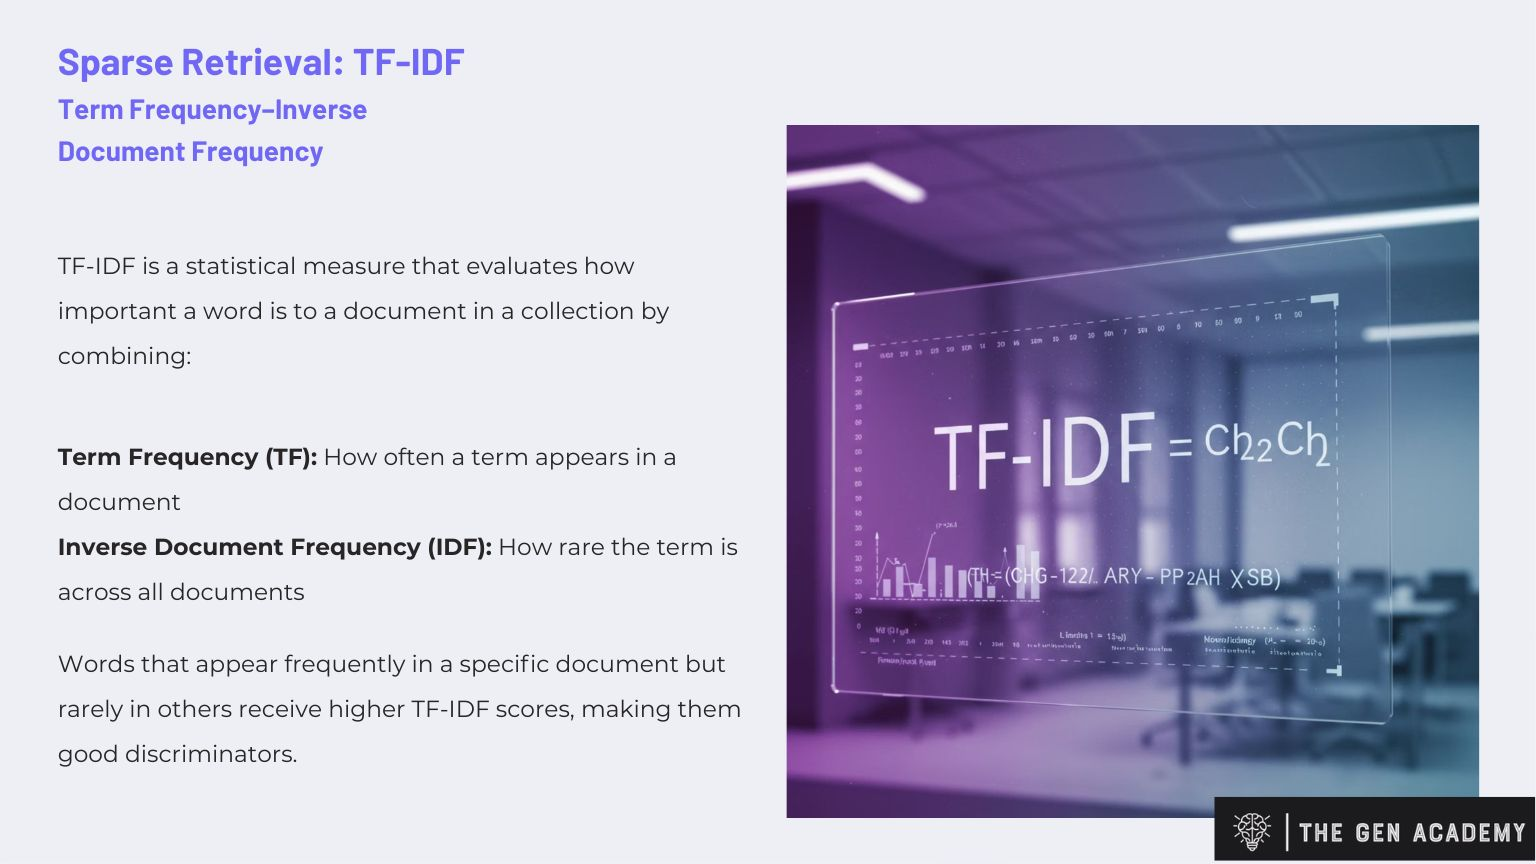


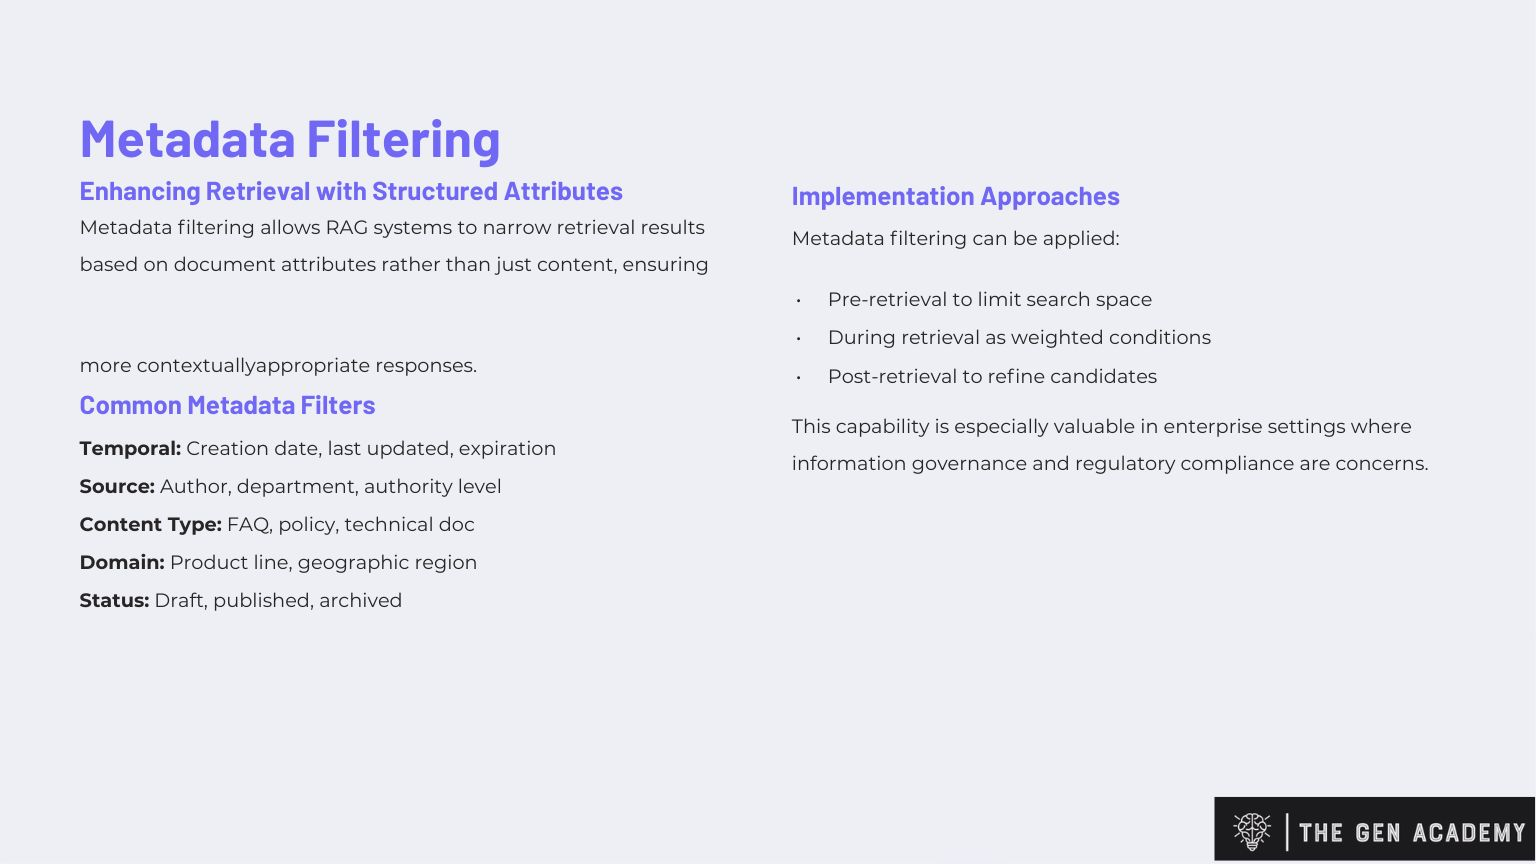


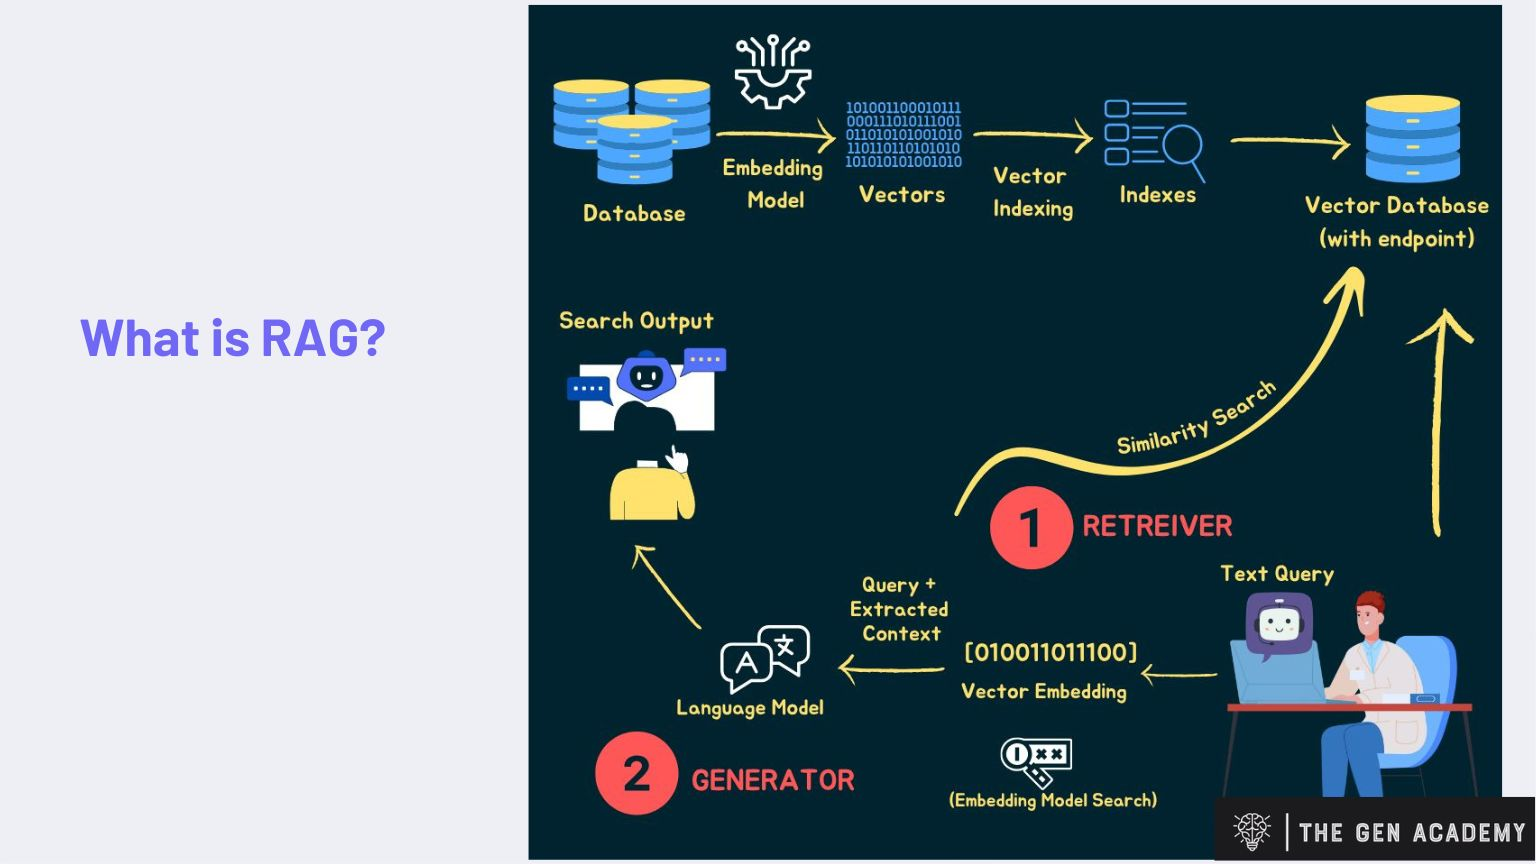

In [8]:
# test retreival
docs = retriever.invoke("What is tfidf")

for doc in docs:
    plt_img_base64(doc.page_content)

##### Generate Answer

In [9]:
## Lets define and llm to generate answer. The llm should support multimodal (text and images)

llm  = ChatOpenAI(temperature = 0, model = "gpt-5-nano")

#### Define the RAG Chain and Helper Functions

We define some helper functions:

-   `resize_base64_image`: Large images can be slow and expensive to process. This function resizes the retrieved images to a more manageable size before sending them to the LLM.
-   `process_retreived_docs`: This function takes the documents from the retriever and formats them into a dictionary containing the resized, base64-encoded images.
-   `prompt_generator`: This is a crucial function that constructs the final prompt for the multimodal LLM. It takes the user's question and the retrieved images and assembles them into a structured message list that the LLM can process. It also includes instructions for the LLM on how to answer.

In [10]:
def resize_base64_image(base64_string, size=(500, 500)):
    # Decode the Base64 string
    img_data = base64.b64decode(base64_string)
    img = Image.open(io.BytesIO(img_data))

    # Resize the image
    resized_img = img.resize(size, Image.LANCZOS)

    # Save the resized image to a bytes buffer
    buffered = io.BytesIO()
    resized_img.save(buffered, format=img.format)

    # Encode the resized image to Base64
    return base64.b64encode(buffered.getvalue()).decode("utf-8") 
    

def process_retreived_docs(docs):
    images = []
    for doc in docs:

        images.append(resize_base64_image(doc.page_content))

    return {'images' : images}

# helper function to generate prompt
def prompt_generator(data_dict):
    messages = []
    question = data_dict['question']

    # Adding image(s) to the messages if present
    if data_dict["image_context"]["images"]:
        print('Retreived Images.....')
        for image in data_dict["image_context"]["images"]:
            plt_img_base64(image) # to see what has been retrevied
            image_message = {
                "type": "image",
                "source_type": "base64",
                "mime_type": "image/jpeg",
                "data": image,
            }
            messages.append(image_message)

    # Adding the text message for analysis
    text_message = {
        "type": "text",
        "text": (
                f"""Use the following pieces of context to answer the question at the end.
                If you don't know the answer, just say that you don't know, don't try to make up an answer.
                Use three sentences maximum and keep the answer as concise as possible.
                Always say "thanks for asking!" at the end of the answer.

                Question: f{question}

                Helpful Answer:"""
        ),
    }
    messages.append(text_message)

    # print(messages)
    return [HumanMessage(content=messages)]

#### Construct the RAG Chain

In [11]:
# Define the complete RAG pipeline using LCEL

chain = (
    {
        'image_context' : retriever | RunnableLambda(process_retreived_docs),
        "question" : RunnablePassthrough()
    }
    | RunnableLambda(prompt_generator)
    | llm
    | StrOutputParser()
)

Retreived Images.....



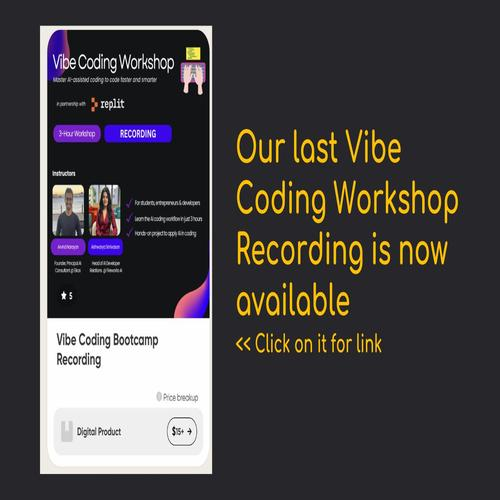


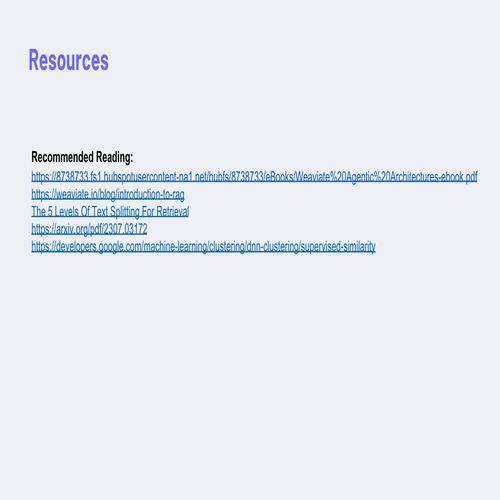


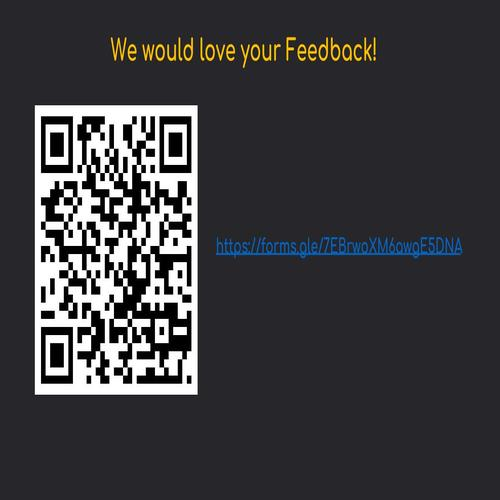

In [12]:
user_question = "How much does the Vibe coding recording cost"

# execute the RAG pipeline
generated_answer = chain.invoke(user_question)

In [13]:
# the final generated answer
print(f'AI Response : {generated_answer}')

AI Response : The Vibe Coding Recording is priced at $15+ as a digital product. thanks for asking!


### Approach 2 : Parse Document into Text and Images

While Approach 1 is simple, it treats each image as an atomic unit. For documents like PDFs or presentations, a single page can contain both crucial text and relevant images.

In this second approach, we will first parse a PDF document to extract text chunks and images separately. We will then embed both the text and the images into the same vector store. This allows for more granular retrieval, where a query might return a combination of specific text paragraphs and images that are most relevant to the user's question.


We will use the `pymupdf` library to parse a PDF file. We first define the path to our source PDF and create directories to store the extracted text files and images.

In [14]:
filepath = './RAG-Part1-Slides.pdf'
base_dir = 'Parsed-Data'

doc = pymupdf.open(filepath) #pymupdf document object


#create directories for parsed data
directories = ["images", "text"]
for dir in directories:
    os.makedirs(os.path.join(base_dir, dir), exist_ok=True)

We create two functions to handle the extraction process:

-   `process_text`: This function extracts all text from a given page of the PDF and saves it as a `.txt` file.
-   `process_images`: This function finds all images on a given page, extracts them, and saves them as `.png` files.

In [15]:
# Helper functions to parse the doc for text and images

def process_text(page, page_num, base_dir, text_chunks):
    page_text = page.get_text()
    text_chunks.append(page_text)
    with open(os.path.join(base_dir, "text", f"page_{page_num}.txt"), "w") as f:
        f.write(page_text)

# Process images
def process_images(page, page_num, base_dir, items):
    images = page.get_images()
    for idx, image in enumerate(images):
        xref = image[0]
        pix = pymupdf.Pixmap(doc, xref)
        image_path = f"{base_dir}/images/{os.path.basename(filepath)}_image_{page_num}_{idx}_{xref}.png"
        pix.save(image_path)
        with open(image_path, 'rb') as f:
            encoded_image = base64.b64encode(f.read()).decode('utf8')
        image_uris.append(image_path)

In [16]:
# parse the documents

text_chunks = []
image_uris = []

for page_num in range(doc.page_count):
    page = doc.load_page(page_num)
    process_text(page, page_num, base_dir, text_chunks)
    process_images(page, page_num, base_dir, image_uris)

In [17]:
# initialize a New Vector Store Collection

vector_store2 = Chroma(
    collection_name="mm_rag_clip2",
    embedding_function=OpenCLIPEmbeddings(),
    persist_directory="./chroma_db",  # Where to save data locally
)

#### Embed Both Text and Images

This is the key step of this approach. We add both the extracted images and the text chunks to the same vector store collection.

-   `vector_store2.add_images(image_uris)`: Embeds the saved image files.
-   `vector_store2.add_texts(text_chunks)`: Embeds the extracted text content.

Now, our vector store contains embeddings for both modalities from the same source document.

In [18]:
# embedd images and texts

vector_store2.add_images(image_uris)



['a8c72330-5a78-439d-811b-af4ac6fd2afc',
 '65fd3323-97a2-414a-9df9-3f96dfbd2aae',
 'e73d4dcd-30e2-4d5f-9e43-864610abe6fe',
 '8ee6291c-789e-40be-aef8-349b26a568ab',
 '08d63040-0e10-4478-95b9-8681a935d3f1',
 '0211bfb9-9f51-405c-a9ae-4263c3e22a85',
 'bef6926e-4fde-40cb-b4fe-a07ada0b369a',
 'd820cf46-7316-4a6b-af02-af13423da1e7',
 'e5c468c1-f2bd-4a65-a35b-0d6e2067e7cc',
 'e39412dc-e2ed-420a-b38e-be4aea3fcae6',
 '645b5263-08e0-4321-8315-a776a91d5ff3',
 '4b896889-ddf6-4106-89b6-3f70b6a70315',
 'c00efd63-e9cf-49b2-9f4b-63e5d00d52dd',
 '314edfcc-9b06-4957-aeec-6b51f21235c4',
 'dcd612d3-8f51-410d-9c9a-1db9a76f8369',
 '4140df1a-bf61-4558-9fd3-0bd3c28a7ac5',
 'ae4f9a5e-85cf-449a-aff1-9f33609cd8ac',
 '4ad2d929-a789-4aa5-851e-ded625293f3e',
 '6cbf8349-a981-45df-8e01-2cd1598d378b',
 '829f590d-0ee3-4dc8-a0c8-208a25219525',
 '7d2c1953-02bd-41b1-97f8-a5734569af7a',
 '0dd79feb-8ad7-4ae0-a08b-6193b813695c',
 'c97d72bb-8d6e-4233-8606-d5d2d2d6f192',
 '18bb88ec-6948-44d1-b601-b9c966e4a854',
 'f66a4f58-8476-

In [19]:
vector_store2.add_texts(text_chunks)

['f0c7e3e6-4563-4f55-b4fc-13811e71c8b3',
 'a39f9fc8-e24f-48cf-8cf3-fee3197e9f0c',
 '626b101b-1ea2-4240-9baa-36cf58f38b77',
 '18b45a83-5e10-49aa-9b73-a41ee1ed0eb1',
 '0cb5a664-8803-4242-a4e2-c834aab50604',
 '54a38d14-5257-40aa-9b3b-29c710e7d3a8',
 'ef5fc898-75bc-4560-bcd9-2604e5d358de',
 '94c8a97c-c834-45ca-b8cc-5fe01046eda2',
 '5e364c83-0677-419f-af18-e5af8dca4109',
 'e269030d-bf97-43f8-b98a-7c3a2b5d3d09',
 'a532b2a2-700c-4257-8c44-79d7a3a9074f',
 '20eee2ab-31ff-4fc0-80f3-57a0a8227ff3',
 'b7c17e86-d757-4695-8a87-99b5d3e4d462',
 '1301ba50-98e4-42a7-836c-f511fe095c02',
 '05d4bde7-77ba-435f-8b2b-541a3d69ce36',
 '8b46f177-d1c6-433e-86d0-e54d0808d213',
 'f62d0377-fbbd-4a83-b473-fab2f117afbb',
 '64b273ea-9367-4f6c-a24a-ad185f44852d',
 'e85af869-690c-4c5b-90f9-6dab351f480c',
 '7336f8fe-749e-4206-b0da-28174ee19ada',
 'b42b2d10-556b-4c9b-9cf8-088ab7e7c8be',
 '8606b42b-2247-4a2f-b2c3-40cb3d6f9101',
 '2b4461eb-ba6f-45bb-b147-7cfd847feb7d',
 'b0fd21ce-d129-4850-a7c9-bc470c263b2e',
 'ccc530b0-f480-

In [20]:
# helper function to check if the retreived chunk is an image
def is_base64(s):
    """Check if a string is Base64 encoded"""
    try:
        return base64.b64encode(base64.b64decode(s)) == s.encode()
    except Exception:
        return False

In [21]:
# Create a new retriever from our second vector store.
retriever2 = vector_store2.as_retriever(search_kwargs={"k": 5})

##### Test the Retriever

What is RAG?

Who are we?




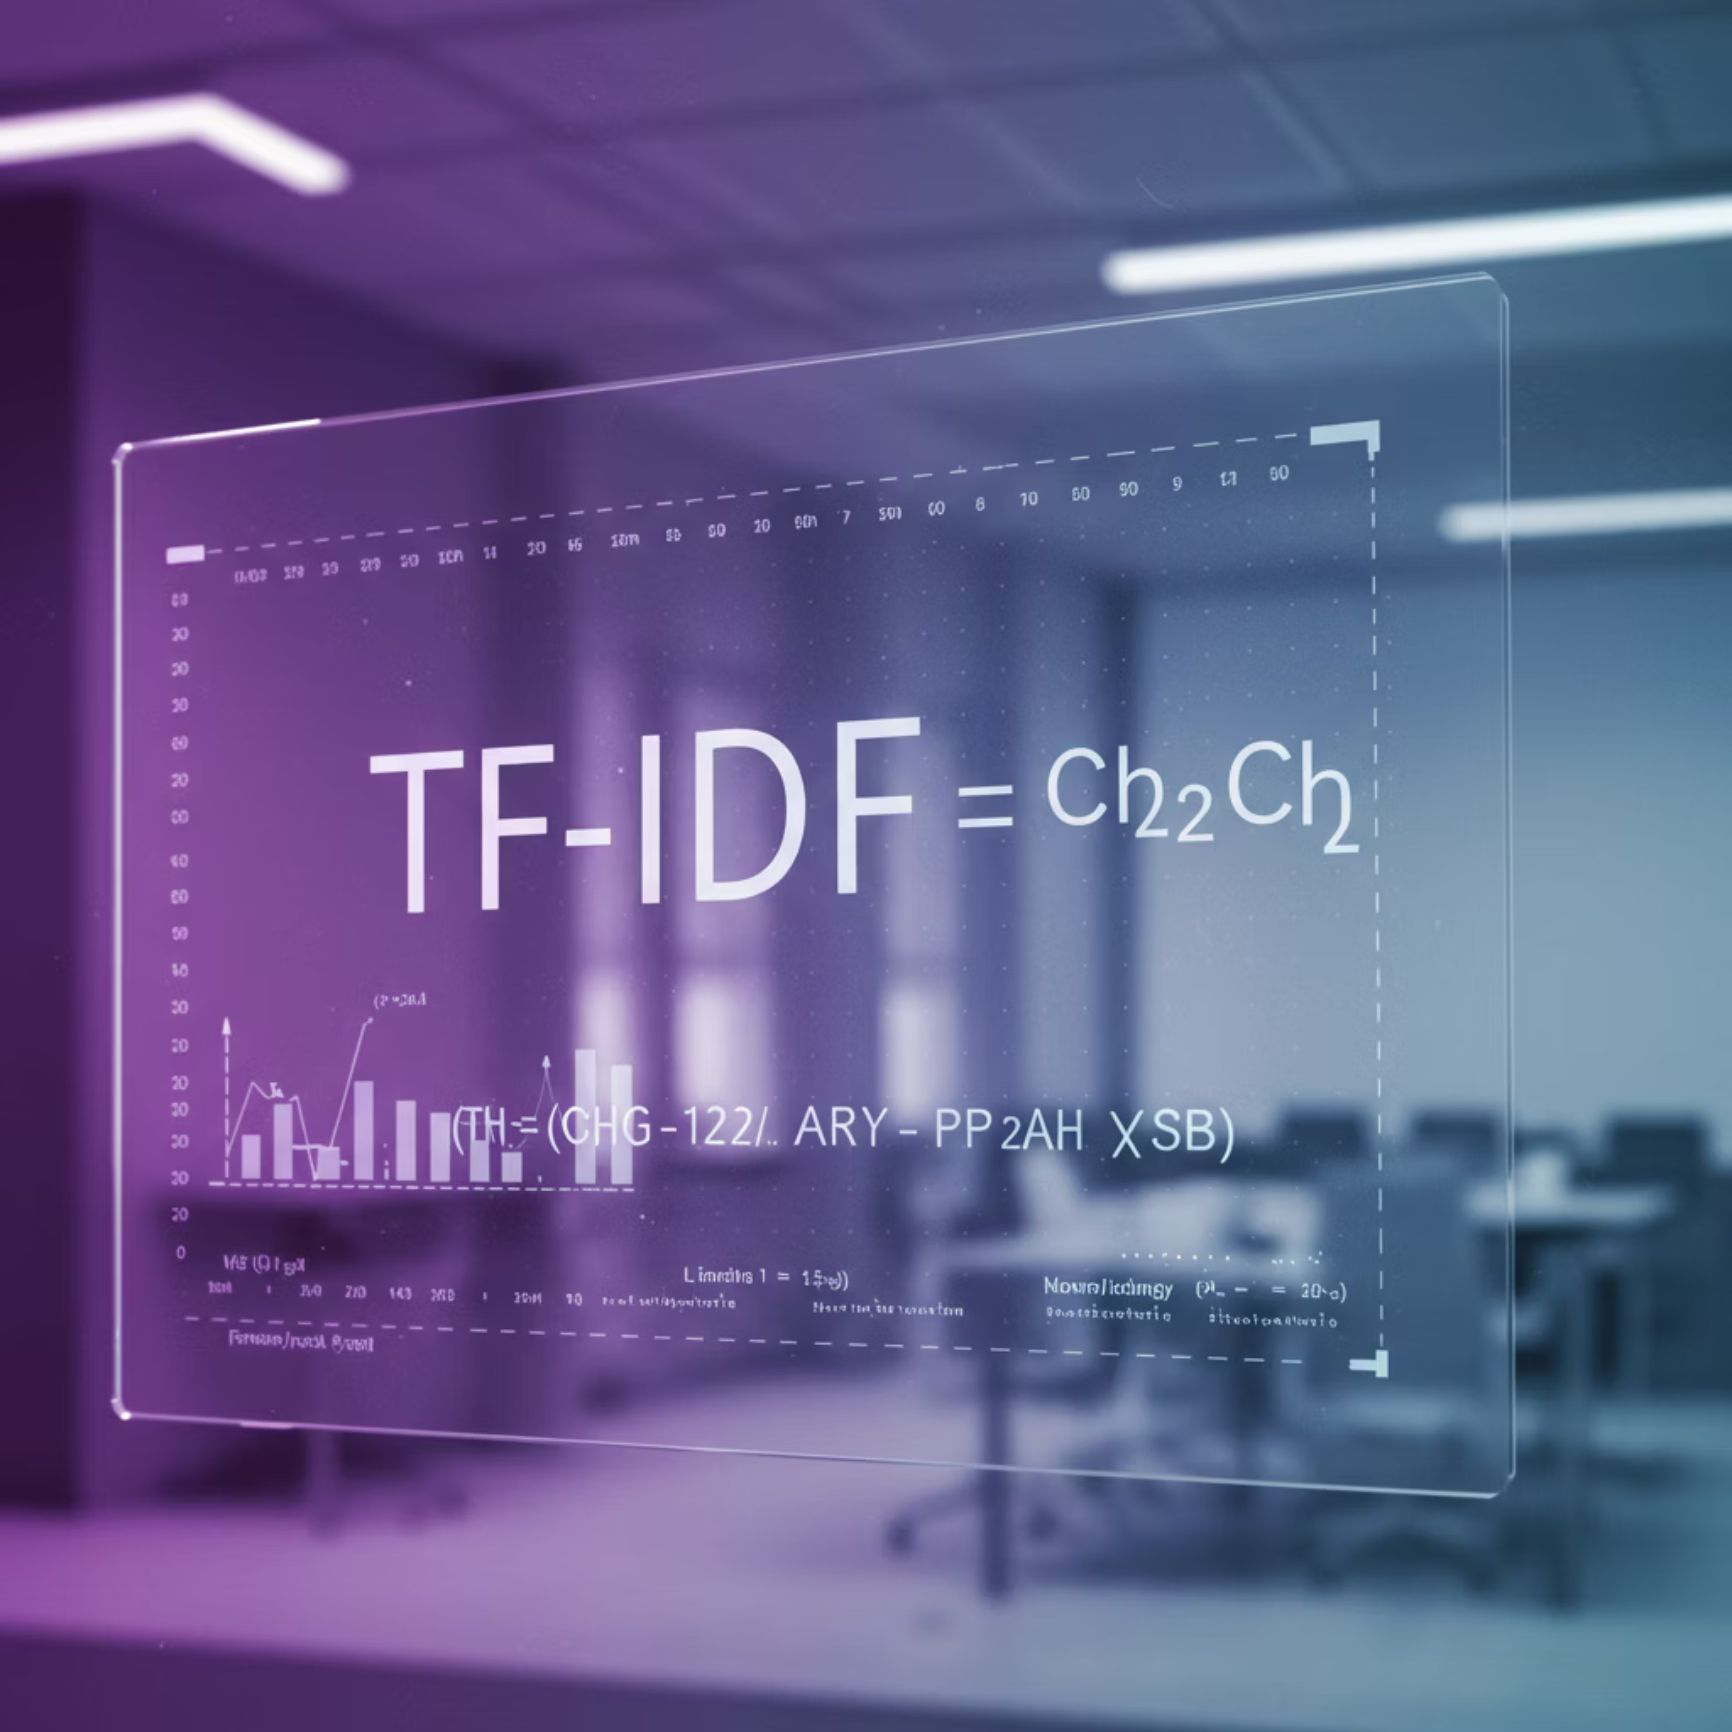

Demo Time!

Sparse Retrieval: TF-IDF
Term Frequency–Inverse 
Document Frequency
TF-IDF is a statistical measure that evaluates how 
important a word is to a document in a collection by 
combining:
Term Frequency (TF): How often a term appears in a 
document
Inverse Document Frequency (IDF): How rare the term is 
across all documents
Words that appear frequently in a speciﬁc document but 
rarely in others receive higher TF-IDF scores, making them 
good discriminators.



In [22]:
docs = retriever2.invoke("What is tfidf?")

for doc in docs: 
    if is_base64(doc.page_content):
        plt_img_base64(doc.page_content)
    else:
        print(doc.page_content)

Our processing and prompting logic needs to be updated to handle the mixed-modality context.

-   `process_retreived_docs`: This function now iterates through the retrieved documents, using `is_base64` to sort them into separate lists for `images` and `text`.
-   `prompt_generator`: The prompt constructor is updated to handle both image and text context. It adds the retrieved images to the message list and also inserts the retrieved text chunks into the final text prompt for the LLM.

In [23]:
def prompt_generator(data_dict):
    messages = []
    question = data_dict['question']

    # Adding image(s) to the messages if present
    if data_dict["context"]["images"]:
        print('Retreived Images.....')
        for image in data_dict["context"]["images"]:
            plt_img_base64(image) # to see what has been retrevied
            image_message = {
                "type": "image",
                "source_type": "base64",
                "mime_type": "image/jpeg",
                "data": image,
            }
            messages.append(image_message)

    # Adding the text message for analysis
    text_message = {
        "type": "text",
        "text": (
                f"""Use the following pieces of context to answer the question at the end.
                If you don't know the answer, just say that you don't know, don't try to make up an answer.
                Use three sentences maximum and keep the answer as concise as possible.
                Always say "thanks for asking!" at the end of the answer.

                Question: f{question}

                Text Context:
                {data_dict["context"]["text"]}

                Helpful Answer:"""
        ),
    }
    print('Retreived Texts.....')
    print(data_dict["context"]["text"])
    
    messages.append(text_message)

    return [HumanMessage(content=messages)]

In [24]:
def process_retreived_docs(docs):
    images = []
    text = []
    for doc in docs:
        if is_base64(doc.page_content):
            images.append(resize_base64_image(doc.page_content))
        else:
            text.append(doc.page_content)
    # print({'images' : images, 'text' : text})
    return {'images' : images, 'text' : text}

#### Construct the RAG Chain

In [25]:
chain = (
    {
        'context' : retriever2 | RunnableLambda(process_retreived_docs),
        "question" : RunnablePassthrough()
    }
    | RunnableLambda(prompt_generator)
    | llm
    | StrOutputParser()
)

Retreived Images.....



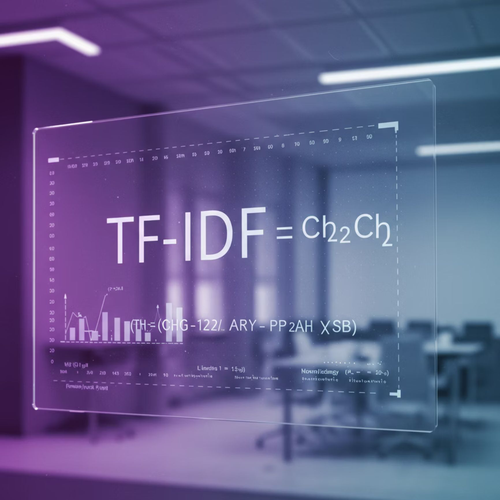

Retreived Texts.....
['What is RAG?\n', 'Who are we?\n', 'Sparse Retrieval: TF-IDF\nTerm Frequency–Inverse \nDocument Frequency\nTF-IDF is a statistical measure that evaluates how \nimportant a word is to a document in a collection by \ncombining:\nTerm Frequency (TF): How often a term appears in a \ndocument\nInverse Document Frequency (IDF): How rare the term is \nacross all documents\nWords that appear frequently in a speciﬁc document but \nrarely in others receive higher TF-IDF scores, making them \ngood discriminators.\n', 'Demo Time!\n']


In [26]:
user_question = "What is tfidf"

# execute the RAG pipeline
generated_answer = chain.invoke(user_question)

In [27]:
print(f'AI Response : {generated_answer}')

AI Response : TF-IDF is a statistical measure that determines how important a word is to a document within a collection. It combines Term Frequency (TF) – how often the term appears in the document – with Inverse Document Frequency (IDF) – how rare the term is across all documents. Words with high TF but low overall document frequency get high TF-IDF scores, helping discriminate between documents. thanks for asking!
